# TS3: Análisis de Fourier: FFT, desparramo, interpolación y ventaneo.
## Alumno: Matías Carbajal
## Materia: Análisis y Procesamiento de Señales (APS)
## Carrera: Ingeniería Telecomunicaciones
## Fecha: 13 de septiembre de 2026

# 1. Introducción teórica
## 1.1. Espectral leakage

El **spectral leakage** o **desparramiento espectral** se produce cuando, al calcular la FFT de una señal de duración finita, la energía de una componente frecuencial no queda concentrada en un único bin, sino que se **distribuye entre varios bins del espectro**.

Una de las situaciones más comunes en las que aparece es cuando la frecuencia de la señal **no es un múltiplo entero de la resolución espectral**:

$$
f_0 \neq k\Delta f
$$

donde

$$
\Delta f=\frac{f_s}{N}
$$

es la resolución espectral de la FFT.

La causa del fenómeno está relacionada con que, al tomar una cantidad finita de muestras, estamos **recortando la señal en el tiempo**. Esto equivale a multiplicarla por una **ventana rectangular**.

Por lo tanto, en frecuencia, la señal original se convoluciona con la transformada de Fourier de la ventana rectangular, que tiene la forma de una **sinc** (o, en el caso de la DFT, un **núcleo de Dirichlet**).

Si la frecuencia de la señal coincide exactamente con un bin de la FFT,

$$
f_0=k_0\Delta f
$$

los puntos donde se evalúa el espectro coinciden con los **cruces por cero de los lóbulos laterales** de la respuesta de la ventana. De esta manera, la energía queda concentrada en el bin correspondiente a la frecuencia de la señal.

En cambio, si la frecuencia no coincide con un múltiplo entero de $Delta f$, los bins de la FFT ya no coinciden con los cruces por cero de la sinc. Por lo tanto, los bins vecinos toman valores distintos de cero y la energía de la señal aparece **desparramada alrededor de la frecuencia original**, produciendo el fenómeno conocido como **spectral leakage**.

---

La respuesta en frecuencia de la ventana rectangular de longitud $N$, centrada en el origen temporal o desplazada para ser causal, viene dada por el **núcleo de Dirichlet**:

$$
W_R[k]
=
\frac{sinc(\pi k)}
{sinc\left(\frac{\pi k}{N}\right)}
e^{-j\pi k\frac{N-1}{N}}
$$

con

$$
W_R[0]=N.
$$

Una senoidal discreta pura de frecuencia $f_0$ tiene una representación en frecuencia equivalente a una **periodicidad de deltas de Dirac** ubicadas en el índice correspondiente a dicha frecuencia.

Al realizar la convolución en frecuencia,

$$
X_R[k]=X[k]*W_R[k],
$$

el espectro resultante es el kernel de Dirichlet desplazado a la posición del tono.

Si la componente de la señal se representa mediante una delta:

$$
X[k]=A\delta[k-k_0],
$$

entonces:

$$
X_R[k]
=
A\delta[k-k_0]*W_R[k]
$$

y, utilizando la propiedad de la convolución con una delta:

$$
\boxed{
X_R[k]=A\,W_R[k-k_0]
}
$$

Es decir, la delta **desplaza el núcleo de Dirichlet hasta la posición del tono**. Por eso, en lugar de observar una única delta, aparecen el lóbulo principal y los lóbulos laterales del núcleo de Dirichlet.

### 1.2.Análisis de los bins

Evaluamos la función en un *bin* cualquiera \(k\), donde definimos:

$$
r=k-k_0.
$$

Entonces:

$$
W_R[r]
=
\frac{sinc(\pi r)}
{sinc\left(\frac{\pi r}{N}\right)}
e^{-j\pi r\frac{N-1}{N}}.
$$

#### 1.2.1 Si $k_0$ coincide con un bin

Si

$$
f_0=k_0\Delta f
$$

con $k_0$ entero, entonces $r=k-k_0$ también es entero.

Para todos los bins distintos del correspondiente al tono,

$$
r\neq0,
$$

tenemos:

$$
\sin(\pi r)=0.
$$

Por lo tanto:

$$
W_R[r]=0.
$$

Así, los lóbulos laterales caen exactamente sobre los bins donde el núcleo de Dirichlet tiene sus cruces por cero y la energía queda concentrada en el bin $k_0$.

#### 1.2.2 Si $k_0$ no coincide con un bin

Si la frecuencia no coincide con un bin de la FFT,

$$
f_0\neq k_0\Delta f,
$$

el centro del núcleo de Dirichlet queda **entre dos bins**.

En este caso, para los valores enteros de $k$, $r=k-k_0$ ya no es entero. Por lo tanto:

$$
sinc(\pi r)\neq0
$$

y los bins vecinos toman valores distintos de cero.

Como consecuencia, la energía de la componente frecuencial se distribuye entre varios bins, produciendo el **spectral leakage**.

## 1.2. Zero Padding e Interpolación Espectral

La técnica de *Zero Padding* consiste en rellenar o extender una secuencia discreta de tiempo de longitud $N$ agregando $M$ ceros al final, obteniendo una nueva secuencia de longitud total $N_{pad} = N + M$:

$$x_{pad}[n] = \begin{cases} x[n], & 0 \le n \le N-1 \\ 0, & N \le n \le N_{pad}-1 \end{cases}$$

Al calcular la DFT (o FFT) sobre esta nueva secuencia extendida, se obtienen $N_{pad}$ muestras en el dominio de la frecuencia.

---

el *Zero Padding*

* **NO aumenta la resolución espectral física:**
  La resolución física de una señal depende **exclusivamente de la cantidad de muestras reales extraídas en el dominio del tiempo** ($T_0 = N \cdot T_s$). Agregar ceros no aporta información nueva sobre la señal ni aumenta la capacidad de distinguir dos tonos que están más cercanos entre sí que el ancho del lóbulo principal de la ventana.

* **SÍ realiza una interpolación en el dominio de la frecuencia:**
  Desde el punto de vista matemático, la DFT de la señal extendida es equivalente a **DTFT** continua de la señal original de $N$ puntos en una grilla de frecuencias más densa (paso de frecuencia ficticio $\Delta f_{pad}$):

$$\Delta f_{pad} = \frac{f_s}{N_{pad}} < \frac{f_s}{N}$$

---
Al aplicar *Zero Padding* (por ejemplo, agregando $9N$ ceros para obtener $N_{pad} = 10N$):

1. **Evaluación de la DTFT continua:** Permite observar con gran detalle y suavidad la forma continua de la sinc , haciendo visibles tanto el lóbulo principal como la estructura completa de los lóbulos secundarios.
2. **Localización de Picos Asincrónicos:** Cuando ocurre el fenómeno de desintonía , el verdadero pico máximo de la sinc no cae en una muestra de la DFT original. El *zero padding* interpola muestras muy cercanas a la cresta del lóbulo principal, permitiendo estimar con mayor precisión la posición del máximo y la energía real del tono.

# 2. Sintonización de señales  

In [21]:
## Librería y parámetros

In [22]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

# Parámetros del sistema
N  = 1000
fs = 1000
ff = 1000 
# SNRdb = 40
vmax = np.sqrt(2)   
dc = 0
ph = np.pi/2
delta_f = fs/N

def mi_funcion_sen(vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000):
    tt = np.arange(0, nn / fs, 1 / fs)
    xx = dc + vmax * np.sin(2 * np.pi * tt * ff + ph)
    return (tt, xx)

#### Señales de distinta frecuencia (N/4 , N/4+0.25 , N/4+0.5

In [23]:
k_o=N/4
f_o=k_o*delta_f

tt, xx1 = mi_funcion_sen(vmax=vmax, dc=dc, ff=f_o, ph=ph, nn=N, fs=fs)

k_o=N/4 + 0.25
f_o=k_o*delta_f

tt, xx2 = mi_funcion_sen(vmax=vmax, dc=dc, ff=f_o, ph=ph, nn=N, fs=fs)

k_o=N/4 + 0.5
f_o=k_o*delta_f

tt, xx3 = mi_funcion_sen(vmax=vmax, dc=dc, ff=f_o, ph=ph, nn=N, fs=fs)

In [24]:
XX1= 1/N *np.fft.fft(xx1)   #
XX2= 1/N *np.fft.fft(xx2)   # FFT 
XX3= 1/N *np.fft.fft(xx3)   #


frecs = np.arange(N) * delta_f   # Eje de frecuencias 

In [25]:
# espectros en dB
espectro_X1 = 10 * np.log10(2 * np.abs(XX1)**2)
espectro_X1 -= np.max(espectro_X1)

espectro_X2 = 10 * np.log10(2 * np.abs(XX2)**2)
espectro_X2 -= np.max(espectro_X2)

espectro_X3 = 10 * np.log10(2 * np.abs(XX3)**2)
espectro_X3 -= np.max(espectro_X3)


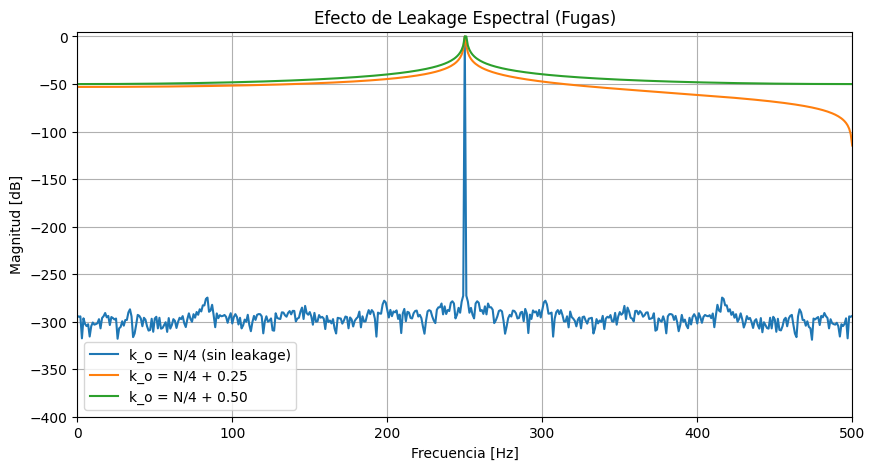

In [26]:
# grafico de las 3 señales
plt.figure(figsize=(10, 5))
plt.plot(frecs, espectro_X1, label="k_o = N/4 (sin leakage)")
plt.plot(frecs, espectro_X2, label="k_o = N/4 + 0.25")
plt.plot(frecs, espectro_X3, label="k_o = N/4 + 0.50")

plt.xlim(0, fs / 2)
plt.ylim(-400, 5)
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Magnitud [dB]")
plt.title("Efecto de Leakage Espectral (Fugas)")
plt.grid(True)
plt.legend()
plt.show()


## 2.1 Zero Padding

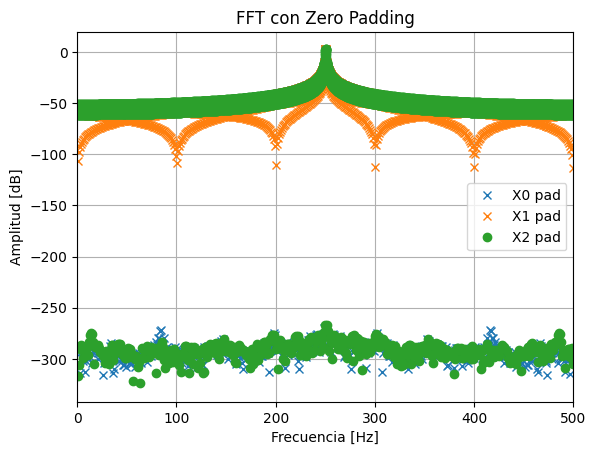

In [27]:
# Zero padding
Npad = 10*N  # 9*N ceros adicionales
xx0_pad = np.pad(xx1, (0, 9*N), 'constant')
xx1_pad = np.pad(xx2, (0, 9*N), 'constant')
xx2_pad = np.pad(xx3, (0, 9*N), 'constant')

# FFT con más puntos
X0_pad = (1 / N) *np.fft.fft(xx0_pad)
X1_pad = (1 / N) *np.fft.fft(xx1_pad)
X2_pad = (1 / N) *np.fft.fft(xx2_pad)

# Nueva frecuencia
f_pad = np.arange(Npad)*(fs/Npad)

# Graficar
plt.figure()
plt.plot(f_pad, 20*np.log10(2*np.abs(X0_pad)),'x',label='X0 pad')
plt.plot(f_pad, 20*np.log10(2*np.abs(X1_pad)),'x',label='X1 pad')
plt.plot(f_pad, 20*np.log10(2*np.abs(X2_pad)),'o',label='X2 pad')
plt.xlim([0, fs/2])
plt.title('FFT con Zero Padding')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [dB]')
plt.legend()
plt.grid()
plt.show()

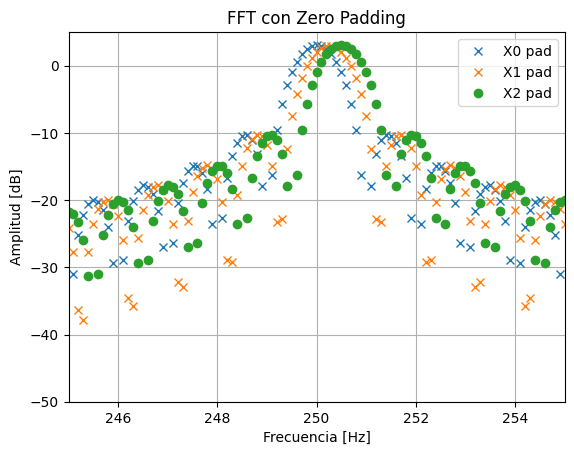

In [28]:

# Graficar
plt.figure()
plt.plot(f_pad, 20*np.log10(2*np.abs(X0_pad)),'x',label='X0 pad')
plt.plot(f_pad, 20*np.log10(2*np.abs(X1_pad)),'x',label='X1 pad')
plt.plot(f_pad, 20*np.log10(2*np.abs(X2_pad)),'o',label='X2 pad')
plt.xlim([245, 255])
plt.ylim([-50, 5])
plt.title('FFT con Zero Padding')
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('Amplitud [dB]')
plt.legend()
plt.grid()
plt.show()

## 2.2 Potencia de las señales 

In [29]:
P1_t = (1 / N) * np.sum(np.abs(xx1)**2)
P2_t = (1 / N) * np.sum(np.abs(xx2)**2)
P3_t = (1 / N) * np.sum(np.abs(xx3)**2)

P1_f = np.sum(np.abs(XX1)**2)
P2_f = np.sum(np.abs(XX2)**2)
P3_f = np.sum(np.abs(XX3)**2)

print(f"--- b) Verificación de Parseval ---")
print(f"Potencia en tiempo:   P1 = {P1_t:.4f} W | P2 = {P2_t:.4f} W | P3 = {P3_t:.4f} W")
print(f"Potencia en freq:     P1 = {P1_f:.4f} W | P2 = {P2_f:.4f} W | P3 = {P3_f:.4f} W\n")

--- b) Verificación de Parseval ---
Potencia en tiempo:   P1 = 1.0000 W | P2 = 1.0010 W | P3 = 1.0000 W
Potencia en freq:     P1 = 1.0000 W | P2 = 1.0010 W | P3 = 1.0000 W



# 3. Análisis de Resultados y Discusión

A partir de los gráficos obtenidos se pueden extraer las siguientes conclusiones principales:

* **Efecto de Desintonía y Leakage Espectral:** 
  Para la señal sintonizada exactamante a un múltiplo entero de $\Delta f$ , el espectro muestra una delta pura centrada en su frecuencia correspondiente. En cambio, para las señales desintonizadas ($k_0 = N/4 + 0.25$ y $k_0 = N/4 + 0.50$), la energía se observa "desparramada" hacia los *bins* vecinos, ensanchando la base y elevando el piso de ruido espectral.

* **Efecto del Zero Padding:** 
  Al aplicar la técnica de *zero padding*, se logra muestrear la DTFT con un paso de frecuencia ficticio más denso ($\Delta f_{pad} = f_s / N_{pad}$). Esto no aumenta la resolución espectral real del sistema, pero permite visualizar con claridad la función $\text{sinc}$ (núcleo de Dirichlet) asociada al ventaneo rectangular implícito, haciendo visibles sus lóbulos secundarios y revelando el pico real de las senoidales asincrónicas.

* **Conservación de la Energía (Teorema de Parseval):** 
  Al calcular la potencia promedio tanto en el tiempo como en la frecuencia mediante el Teorema de Parseval, se verifica de forma rigurosa que la potencia total se mantiene constante en **$1 \text{ W}$** para todos los casos. 

# 4. Conclusiones

En este trabajo se analizó el efecto de sintonizar una señal senoidal a una frecuencia que no es múltiplo entero del paso espectral ($\Delta f$), lo que da origen al fenómeno de desparramo espectral (*spectral leakage*).

A partir del desarrollo teórico y las comprobaciones numéricas, se destacan los siguientes puntos:

* **Conservación de la Potencia vs. Redistribución Espectral:** Mediante la Identidad de Parseval se demostró de forma rigurosa que lo observado en el espectro desintonizado **no constituye una pérdida ni una alteración de la energía real de la señal**, sino una **redistribución de la misma potencia** ($1\text{ W}$) a lo largo de los *bins* adyacentes.
* **Muestreo de la DTFT:** Este fenómeno ocurre porque la DFT muestrea la Transformada de Fourier de Tiempo Discreto (DTFT) continua en puntos donde el numerador del núcleo de Dirichlet (sinc periódica) no se anula, dispersando la energía hacia los lóbulos secundarios del ventaneo rectangular.
* **Importancia Práctica:** Este análisis resulta fundamental en aplicaciones reales de procesamiento digital de señales, donde **resulta prácticamente imposible garantizar que las frecuencias de una señal desconocida sean múltiplos exactos de $\Delta f$**. Por ende, el *leakage* es un efecto inevitable al usar la DFT sobre ventanas finitas, lo que justifica la necesidad de utilizar técnicas de ventaneo (como Hann, Hamming, Blackman) o *zero padding* para mitigar o interpretar adecuadamente la distorsión espectral.